In [1]:
import pandas as pd
df = pd.read_csv('DS_BreastCancer.csv')
# Display all column names
columns = df.columns.tolist()
print(columns)

['chembl_id', 'molregno', 'iupac_name', 'smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ro3_pass', 'num_ro5_violations', 'cx_logp', 'cx_logd', 'molecular_species', 'qed_weighted', 'np_likeness_score', 'ic50_value', 'ic50_units', 'standard_relation', 'target_name', 'target_type', 'cell_description', 'disease_name', 'disease_category', 'mechanism_of_action', 'action_type', 'warning_type', 'warning_description', 'IUPACName']


/var/folders/ky/j161912n7lvbtpf0r6nlk1xh0000gn/T/ipykernel_1267/721474221.py:2: DtypeWarning: Columns (0: warning_description) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('DS_BreastCancer.csv')


In [2]:
import numpy as np

In [3]:
#removed unnecessary columns
df1 = df[['smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ic50_value', 'ic50_units']]

In [4]:
# Remove all null values from df1
df1 = df1.dropna()
print(f"Shape after removing nulls: {df1.shape}")
print(df1.info())

Shape after removing nulls: (43617, 9)
<class 'pandas.DataFrame'>
Index: 43617 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            43617 non-null  str    
 1   molecular_weight  43617 non-null  float64
 2   aLogP             43617 non-null  float64
 3   hba               43617 non-null  float64
 4   hbd               43617 non-null  float64
 5   psa               43617 non-null  float64
 6   rtb               43617 non-null  float64
 7   ic50_value        43617 non-null  float64
 8   ic50_units        43617 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.3 MB
None


In [5]:
#checked whether the units of IC50 values are the sane
print(df1['ic50_units'].unique())

<StringArray>
['nM', 'ug.mL-1', 'ug', 'ug/g', '%', 'pmol/L', '10'5uM', '10'6uM', '10^3nM']
Length: 9, dtype: str


In [6]:
# Keep only rows with nM units
units_to_keep = ['nM']
df1 = df1[df1['ic50_units'].isin(units_to_keep)]
print(f"Shape after filtering: {df1.shape}")
print(df1['ic50_units'].value_counts())

Shape after filtering: (41691, 9)
ic50_units
nM    41691
Name: count, dtype: int64


In [7]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41691 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41691 non-null  str    
 1   molecular_weight  41691 non-null  float64
 2   aLogP             41691 non-null  float64
 3   hba               41691 non-null  float64
 4   hbd               41691 non-null  float64
 5   psa               41691 non-null  float64
 6   rtb               41691 non-null  float64
 7   ic50_value        41691 non-null  float64
 8   ic50_units        41691 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.2 MB


In [8]:
#added the pIC50 column
df1['pic50'] = -np.log10(df1['ic50_value']*1e-9)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Removed 2 rows with max pIC50 = 13.698970004336019
Shape after removing infinite values and max pIC50 outliers: (41687, 10)


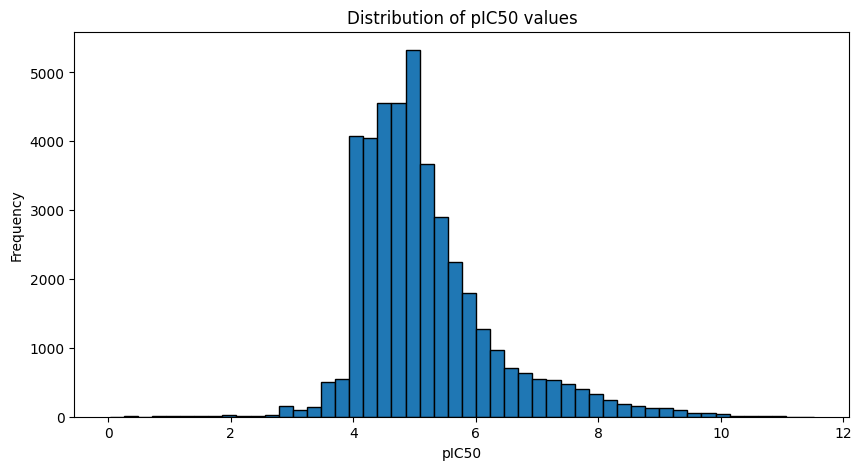

In [9]:
import matplotlib.pyplot as plt
# Remove infinite or NaN values
df1 = df1[np.isfinite(df1['pic50'])]

# Remove all rows with the maximum pIC50 value as outliers (I saw this at the box plot)
max_pic50 = df1['pic50'].max()
removed_count = df1[df1['pic50'] == max_pic50].shape[0]
df1 = df1[df1['pic50'] != max_pic50]
print(f"Removed {removed_count} rows with max pIC50 = {max_pic50}")
print(f"Shape after removing infinite values and max pIC50 outliers: {df1.shape}")

# Visualize the distribution of pIC50 values
plt.figure(figsize=(10, 5))
plt.hist(df1['pic50'], bins=50, edgecolor='black')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.title('Distribution of pIC50 values')
plt.show()


distribution is close to normal

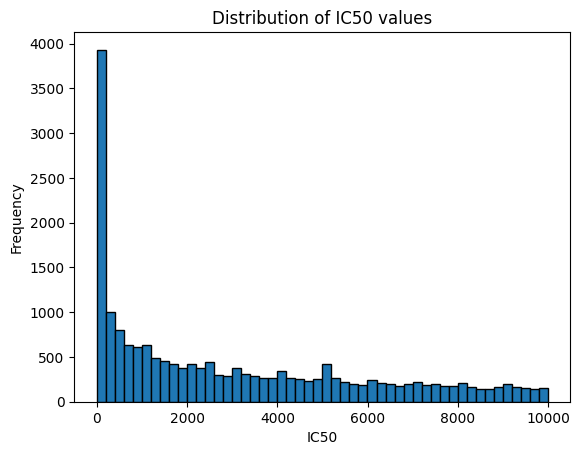

In [10]:
# Visualize the distribution of IC50 values (in nM)
plt.hist(df1['ic50_value'][df1['ic50_value']<10000], bins=50, edgecolor='black')
plt.xlabel('IC50')
plt.ylabel('Frequency')
plt.title('Distribution of IC50 values')
plt.show()

from these 2 graphs it is obvious that pIC50 distr is better for machine learning than IC50 values distr

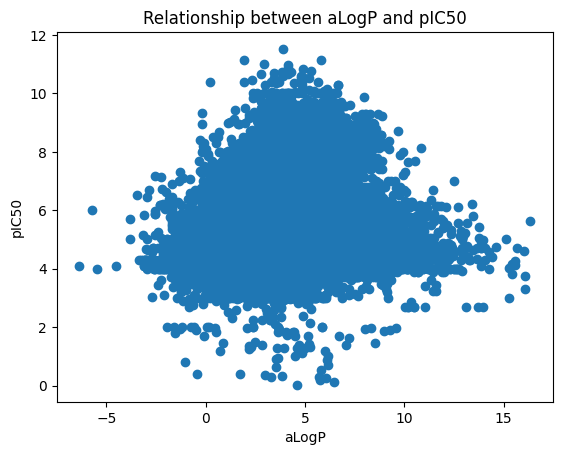

In [11]:
# Visualize the relationship between aLogP and pIC50
plt.scatter(df1['aLogP'], df1['pic50'])
plt.xlabel('aLogP')
plt.ylabel('pIC50')
plt.title('Relationship between aLogP and pIC50')
plt.show()

most active compounds (high pIC50) have approx 2<aLogP<7, which corresponds toLipinski's Rule of 5

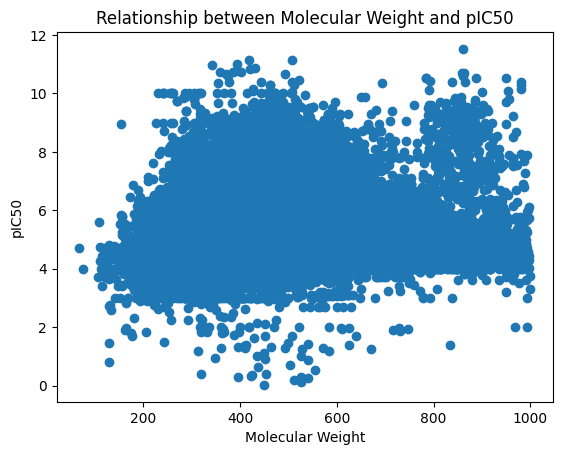

In [12]:
# Visualize the relationship between molecular weight and pIC50
plt.scatter(df1['molecular_weight'], df1['pic50'])
plt.xlabel('Molecular Weight')
plt.ylabel('pIC50')
plt.title('Relationship between Molecular Weight and pIC50')
plt.show()

most active compounds (high pIC50) have approx 200<molecular_weight<500 (small molecules don't have the required affinity to target proteins; large molecules get into cells with difficulty)

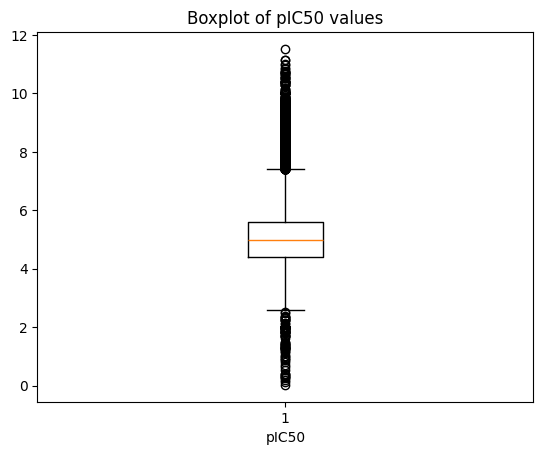

In [13]:
# Visualize the boxplot of pIC50 values
plt.boxplot(df1['pic50'])
plt.xlabel('pIC50')
plt.title('Boxplot of pIC50 values')
plt.show()

there was an obvious outlier at 13.8, I removed it earlier

In [14]:
df1['ic50_value'].describe()

count    4.168700e+04
mean     2.401592e+05
std      9.548970e+06
min      3.000000e-03
25%      2.500000e+03
50%      1.043000e+04
75%      4.000000e+04
max      9.506048e+08
Name: ic50_value, dtype: float64

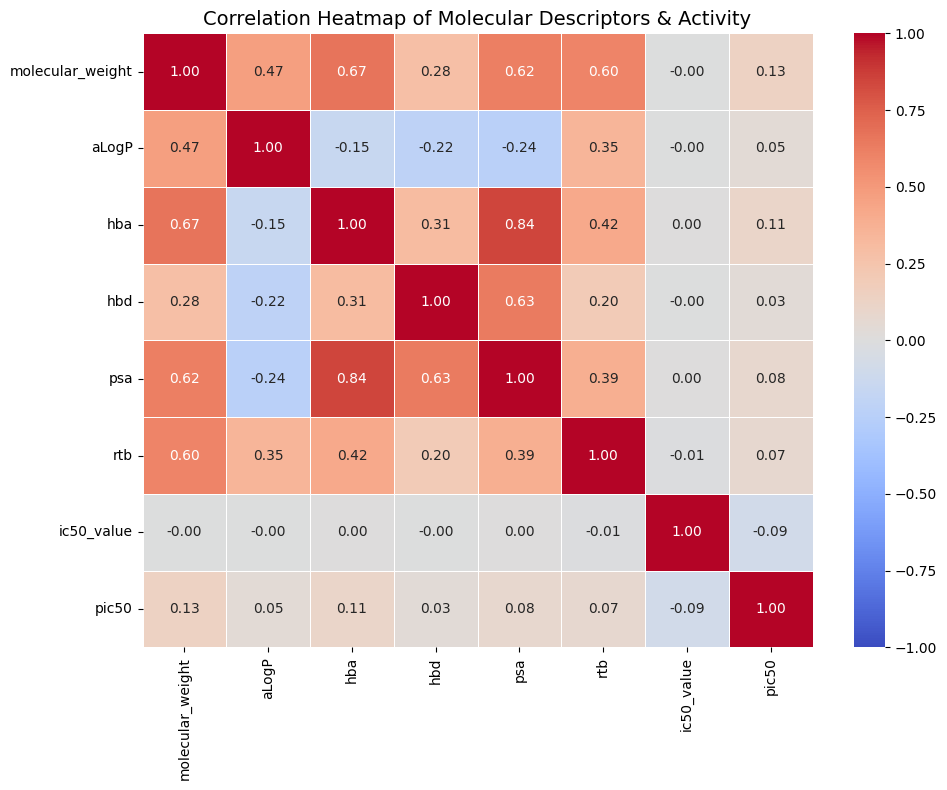

In [15]:
#creating a heatmap of correlations
import seaborn as sns

# 1. Отбираем только числовые колонки для анализа
# (ic50_value и pic50 сильно связаны, но pic50 линейнее, поэтому оставим все для проверки)
numeric_cols = [
    "molecular_weight",
    "aLogP",
    "hba",
    "hbd",
    "psa",
    "rtb",
    "ic50_value",
    "pic50",
]
corr_matrix = df1[numeric_cols].corr(method="pearson")

# 2. Настраиваем размер полотна
plt.figure(figsize=(10, 8))

# 3. Строим тепловую карту
sns.heatmap(
    corr_matrix,
    annot=True,  # Выводить коэффициенты внутри ячеек
    cmap="coolwarm",  # Красивая палитра: синий (минус) -> белый (ноль) -> красный (плюс)
    fmt=".2f",  # Округление до 2 знаков после запятой
    linewidths=0.5,  # Расстояние между ячейками
    vmin=-1,
    vmax=1,  # Границы шкалы
)

# 4. Добавляем заголовки
plt.title("Correlation Heatmap of Molecular Descriptors & Activity", fontsize=14)
plt.tight_layout()

# 5. Показываем график
plt.show()

strong correlation between molecular weight and polar surface area (PSA), since larger molecules tend to have larger surface areas. 

moderate correlation between aLogP andmolecular weight, since larger molecules often have more hydrophobic regions. 

strong correlation between hba and hbd, since both are related to the presence of hydrogen bond donors and acceptors in the molecule.

only -0.09 between pIC50 and ic50_value (cause pIC50 = -log10(IC50), non-linear relationship, see later)

In [16]:
#checking for pIC50 outliers that I mentioned earlier
a=df1[df1['pic50']==df1['pic50'].max()]
print(len(a))
print(a)

1
                                                  smiles  molecular_weight  \
14274  C/C=C(\C)[C@H]1OC(=O)[C@@H](C)NC(=O)[C@H]([C@@...            860.49   

       aLogP   hba  hbd     psa  rtb  ic50_value ic50_units      pic50  
14274   3.89  10.0  4.0  200.75  7.0       0.003         nM  11.522879  


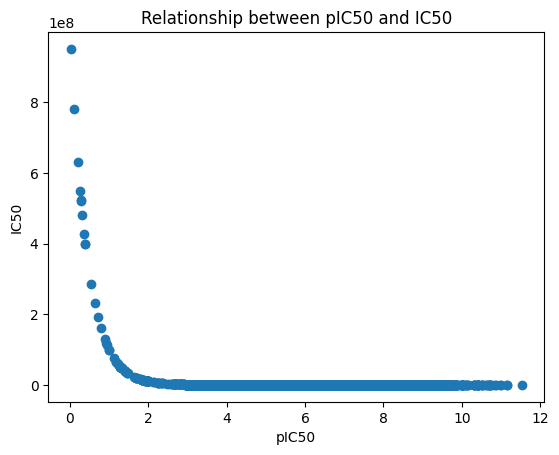

In [17]:
# Visualize the relationship between pIC50 and IC50 values
plt.scatter(df1['pic50'], df1['ic50_value'])
plt.xlabel('pIC50')
plt.ylabel('IC50')
plt.title('Relationship between pIC50 and IC50')
plt.show()

clear exponential relationship

99% of pIC50 values are in 0<IC50<1

but 1% spoils everything, so ic50_values cannot be used for machine learning at all

pIC50 should be used instead

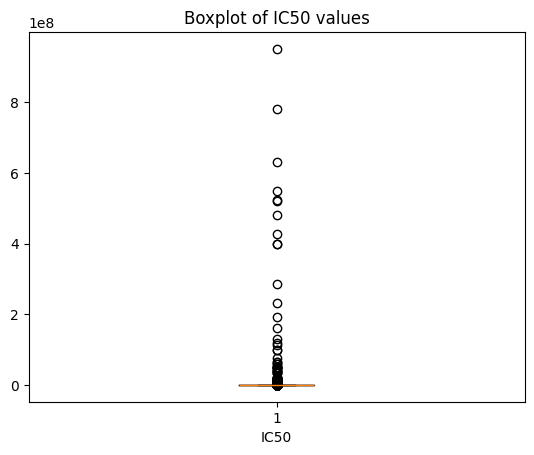

In [18]:
# Visualize the boxplot of IC50 values
plt.boxplot(df1['ic50_value'])
plt.xlabel('IC50')
plt.title('Boxplot of IC50 values')
plt.show()

insane number of outliers

ic50_values cannot be used for machine learning at all, pIC50 should be used instead

no need for ic50_values and ic50_units columns at this point

In [19]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41687 entries, 0 to 46290
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41687 non-null  str    
 1   molecular_weight  41687 non-null  float64
 2   aLogP             41687 non-null  float64
 3   hba               41687 non-null  float64
 4   hbd               41687 non-null  float64
 5   psa               41687 non-null  float64
 6   rtb               41687 non-null  float64
 7   ic50_value        41687 non-null  float64
 8   ic50_units        41687 non-null  str    
 9   pic50             41687 non-null  float64
dtypes: float64(8), str(2)
memory usage: 3.5 MB


In [20]:
df_final = df1.drop(columns=['ic50_value', 'ic50_units'])
print(df_final.info())

<class 'pandas.DataFrame'>
Index: 41687 entries, 0 to 46290
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41687 non-null  str    
 1   molecular_weight  41687 non-null  float64
 2   aLogP             41687 non-null  float64
 3   hba               41687 non-null  float64
 4   hbd               41687 non-null  float64
 5   psa               41687 non-null  float64
 6   rtb               41687 non-null  float64
 7   pic50             41687 non-null  float64
dtypes: float64(7), str(1)
memory usage: 2.9 MB
None


In [21]:
#preparing train data
df_x = df_final.drop(columns=['smiles', 'pic50'])
df_y = df_final['pic50']
print(df_x.info())
print(df_y.info())

<class 'pandas.DataFrame'>
Index: 41687 entries, 0 to 46290
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   molecular_weight  41687 non-null  float64
 1   aLogP             41687 non-null  float64
 2   hba               41687 non-null  float64
 3   hbd               41687 non-null  float64
 4   psa               41687 non-null  float64
 5   rtb               41687 non-null  float64
dtypes: float64(6)
memory usage: 2.2 MB
None
<class 'pandas.Series'>
Index: 41687 entries, 0 to 46290
Series name: pic50
Non-Null Count  Dtype  
--------------  -----  
41687 non-null  float64
dtypes: float64(1)
memory usage: 651.4 KB
None


# Linear Regression Model

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    df_x,
    df_y,
    test_size=0.2,
    random_state=42
)

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

#predicted pic50 values for the test set
y_pred = lr.predict(X_test)

In [24]:
#coeffitions of linear regression model
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})
print(coeff_df.sort_values(by='Coefficient', ascending=False))

            Feature  Coefficient
2               hba     0.021661
3               hbd     0.009870
0  molecular_weight     0.001390
4               psa    -0.002136
5               rtb    -0.003208
1             aLogP    -0.022387


Accuracy evaluation

In [25]:
#Mean Squared Error between predicted and actual pic50 values
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

#Root Mean Squared Error
rmse = np.sqrt(mse)
print("RMSE:", rmse)

#R2
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

MSE: 1.23562632695464
RMSE: 1.1115873006447312
R2: 0.017456844768438784


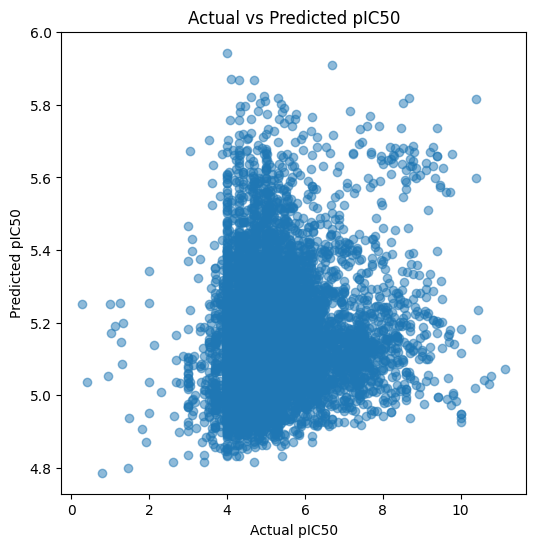

In [26]:
#pred VS exp plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50")
plt.show()

Conclusion: linear regression model is completely useless due to extremely low R2 value (0.017), so it doen't describe the relationship at all. This can be proved by a plot, that looks like a random cloud

R2 with scaling: 0.017456844768439006
RMSE with scaling: 1.111587300644731


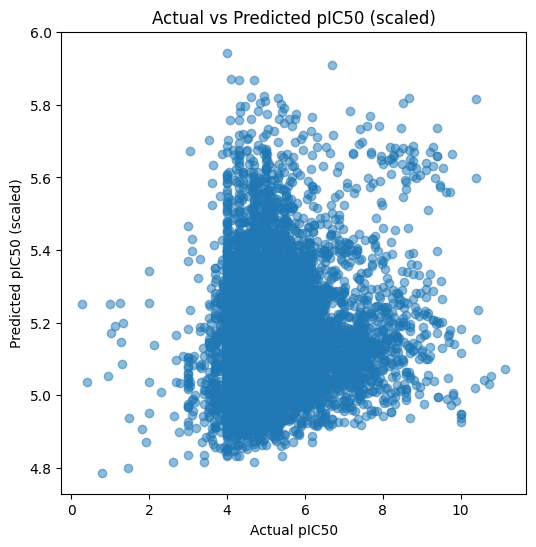

In [27]:
#trying linear regression scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr.fit(X_train_scaled, y_train)
y_pred_scaled = lr.predict(X_test_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)
print("R2 with scaling:", r2_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
print("RMSE with scaling:", rmse_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_scaled, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50 (scaled)")
plt.title("Actual vs Predicted pIC50 (scaled)")
plt.show()

Conclusion: linear regression with scaling model is completely useless as well

# Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [29]:
r2_rf = r2_score(y_test, y_pred_rf)
print("R2 with Random Forest:", r2_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE with Random Forest:", rmse_rf)

R2 with Random Forest: 0.39058558175066815
RMSE with Random Forest: 0.8754354354410853


### Feature importnace

In [30]:
#coefficients of random forest model
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})
print(feature_importance_df.sort_values(by='Importance', ascending=False))

            Feature  Importance
4               psa    0.289822
0  molecular_weight    0.234377
1             aLogP    0.210767
2               hba    0.096480
5               rtb    0.094935
3               hbd    0.073619


Conclusion: polar surface area (PSA), molecular weight, and lipophilicity (aLogP) are the most influential descriptors for predicting anticancer activity (pIC50), which aligns with Lipinski’s rule of five.
RDKit can be used to add more information to decrease overfitting (see later) and identify major and minor features

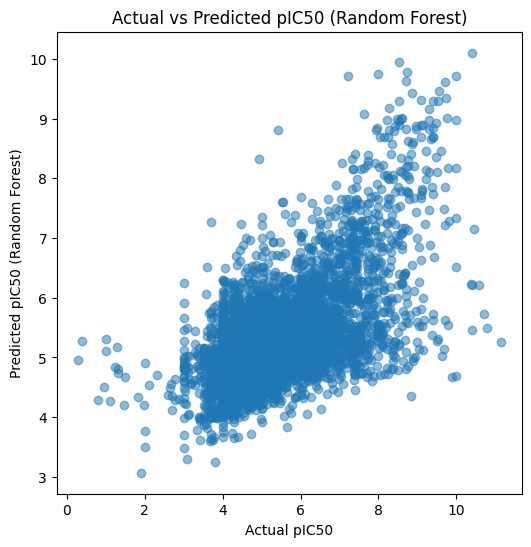

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50 (Random Forest)")
plt.title("Actual vs Predicted pIC50 (Random Forest)")
plt.show()

Conclusion:
R2 value for random forest regression is better than in case of the regular scikit learn model (0.394>0.017). This also can be seen from the plot: it is not as chaotic as the one based on the regular linear regression, at least the upward can be observed, but still there is a large cloud approx in the range between 3 and 8. The model demonstrates moderate predictive capability but is not sufficiently accurate for reliable endpoint prediction in real-world applications.

### Overfitting evaluation

In [43]:
# Overfitting evaluation

# Predictions for training set
y_train_pred_rf = rf.predict(X_train)

# Predictions for test set
y_test_pred_rf = rf.predict(X_test)

# R2 for training set
r2_train_rf = r2_score(y_train, y_train_pred_rf)

# R2 for test set
r2_test_rf = r2_score(y_test, y_test_pred_rf)

# RMSE for training set
rmse_train_rf = np.sqrt(
    mean_squared_error(y_train, y_train_pred_rf)
)

# RMSE for test set
rmse_test_rf = np.sqrt(
    mean_squared_error(y_test, y_test_pred_rf)
)

print("Train R2:", r2_train_rf)
print("Test R2:", r2_test_rf)

print("Train RMSE:", rmse_train_rf)
print("Test RMSE:", rmse_test_rf)

Train R2: 0.8980222655436323
Test R2: 0.39058558175066815
Train RMSE: 0.35350277343655967
Test RMSE: 0.8754354354410853


Conclusion: the model shows clear signs of overfitting, as indicated by a high R² on the training set (0.90) and a substantially lower R² on the test set (≈0.39). This suggests that while the Random Forest model fits the training data well, it fails to generalize effectively to unseen data. As a result, its predictive performance on new compounds is limited, which reduces its reliability for practical anticancer activity prediction.

# XGBoost

In [36]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300, #number of trees
    max_depth=6, #maximum depth of each tree
    learning_rate=0.05, #how much each tree corrects the error
    subsample=0.8, #random sample fraction of the data for each tree to prevent overfitting
    colsample_bytree=0.8, 
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [37]:
r2_xgb = r2_score(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

print("R2:", r2_xgb)
print("RMSE:", rmse_xgb)

R2: 0.2315724835748546
RMSE: 0.9830355263248637


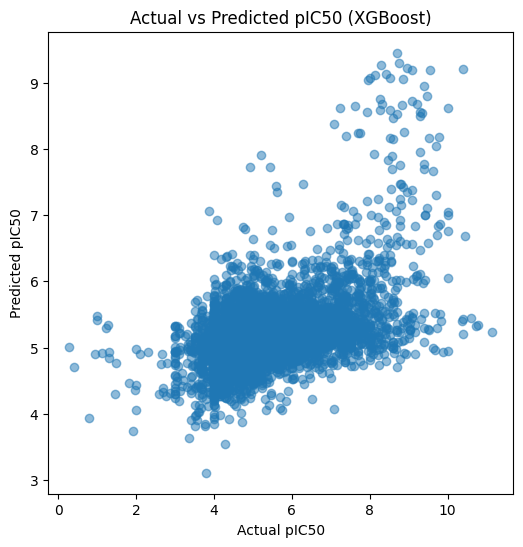

In [39]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.5)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")

plt.title("Actual vs Predicted pIC50 (XGBoost)")

plt.show()

Conclusion: XGBoost performed worse than Random Forest but better than Linear Regression. The R2 value for XGBoost is lower than that of Random Forest, indicating that it explains less variance in the data compared to Random Forest. However, it still performs better than Linear Regression, which has the lowest R2 value among the three models.

### Feature Importnace

In [40]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

print(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    )
)

            Feature  Importance
3               hbd    0.216772
4               psa    0.185071
5               rtb    0.159283
2               hba    0.157179
1             aLogP    0.141245
0  molecular_weight    0.140449


### Overfitting

In [41]:
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print("Train R2:", r2_train)
print("Test R2:", r2_test)

Train R2: 0.3446188585878127
Test R2: 0.2315724835748546


Conclusion: the gap between training and test R² values indicates moderate overfitting, although the model still demonstrates acceptable generalization performance

# LightGBM

In [45]:
from lightgbm import LGBMRegressor

# LightGBM model
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train
lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Metrics
r2_lgbm = r2_score(y_test, y_pred_lgbm)

rmse_lgbm = np.sqrt(
    mean_squared_error(y_test, y_pred_lgbm)
)

print("R2:", r2_lgbm)
print("RMSE:", rmse_lgbm)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 844
[LightGBM] [Info] Number of data points in the train set: 33349, number of used features: 6
[LightGBM] [Info] Start training from score 5.165366
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

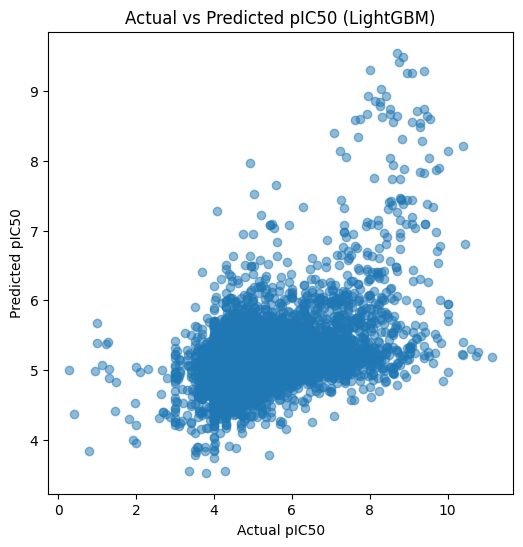

In [46]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lgbm, alpha=0.5)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")

plt.title("Actual vs Predicted pIC50 (LightGBM)")

plt.show()

Conclusion: LightGBM performed a bit worse than XGBoost, these models are close to each other

### Feature importance

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
})

print(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    )
)

            Feature  Importance
4               psa        2323
1             aLogP        1632
0  molecular_weight        1454
5               rtb        1407
2               hba         881
3               hbd         799


### Overfitting

In [48]:
y_train_pred_lgbm = lgbm.predict(X_train)

r2_train_lgbm = r2_score(
    y_train,
    y_train_pred_lgbm
)

r2_test_lgbm = r2_score(
    y_test,
    y_pred_lgbm
)

print("Train R2:", r2_train_lgbm)
print("Test R2:", r2_test_lgbm)

Train R2: 0.2961779503762956
Test R2: 0.21552334867951484


Conclusion: the gap between training and test R² values indicates moderate overfitting, although the model still demonstrates acceptable generalization performance

# CatBoost

In [50]:
from catboost import CatBoostRegressor

# CatBoost model
catboost = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

# Train
catboost.fit(X_train, y_train)

# Predictions
y_pred_cat = catboost.predict(X_test)

# Metrics
r2_cat = r2_score(y_test, y_pred_cat)

rmse_cat = np.sqrt(
    mean_squared_error(y_test, y_pred_cat)
)

print("R2:", r2_cat)
print("RMSE:", rmse_cat)

R2: 0.1602288126426401
RMSE: 1.0276571404633963


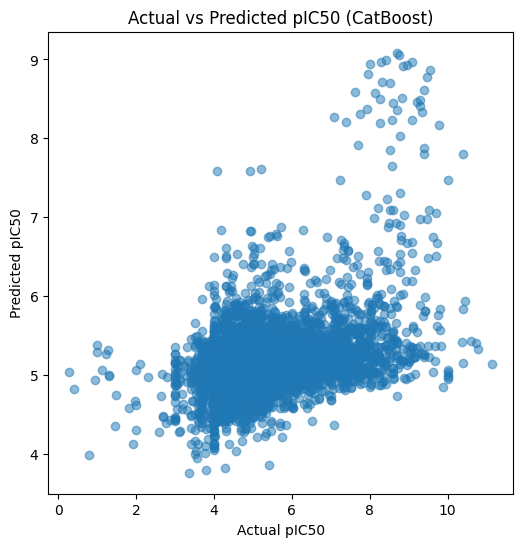

In [51]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_cat, alpha=0.5)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")

plt.title("Actual vs Predicted pIC50 (CatBoost)")

plt.show()

### Feature Importnace

In [52]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': catboost.feature_importances_
})

print(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    )
)

            Feature  Importance
4               psa   23.095184
3               hbd   16.938917
5               rtb   16.821123
1             aLogP   15.439116
0  molecular_weight   14.057635
2               hba   13.648025


### Overfitting

In [53]:
y_train_pred_cat = catboost.predict(X_train)

r2_train_cat = r2_score(
    y_train,
    y_train_pred_cat
)

r2_test_cat = r2_score(
    y_test,
    y_pred_cat
)

print("Train R2:", r2_train_cat)
print("Test R2:", r2_test_cat)

Train R2: 0.2022079063148129
Test R2: 0.1602288126426401


# SVR

In [54]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVR model
svr = SVR(
    kernel='rbf',
    C=10,
    gamma='scale'
)

# Train
svr.fit(X_train_scaled, y_train)

# Predictions
y_pred_svr = svr.predict(X_test_scaled)

# Metrics
r2_svr = r2_score(y_test, y_pred_svr)

rmse_svr = np.sqrt(
    mean_squared_error(y_test, y_pred_svr)
)

print("R2:", r2_svr)
print("RMSE:", rmse_svr)

R2: 0.12051520755732126
RMSE: 1.051675911075847


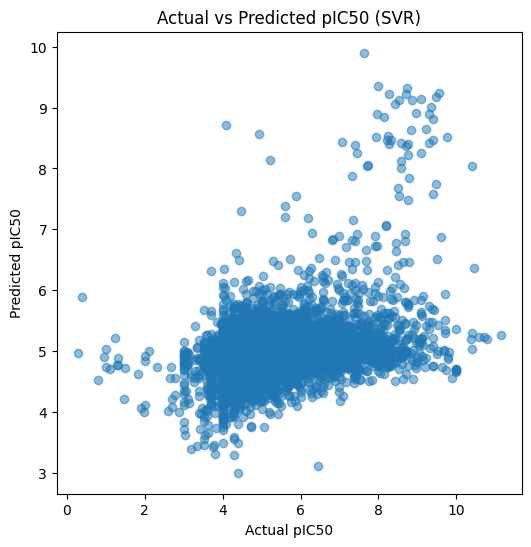

In [55]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_svr, alpha=0.5)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")

plt.title("Actual vs Predicted pIC50 (SVR)")

plt.show()

### Feature Importance

### Overfitting

In [56]:
y_train_pred_svr = svr.predict(X_train_scaled)

r2_train_svr = r2_score(
    y_train,
    y_train_pred_svr
)

r2_test_svr = r2_score(
    y_test,
    y_pred_svr
)

print("Train R2:", r2_train_svr)
print("Test R2:", r2_test_svr)

Train R2: 0.16024078538629227
Test R2: 0.12051520755732126


# Overall Table

In [60]:
# Create comparison table

results_df = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost',
        'SVR'
    ],

    'R2': [
        r2,
        r2_rf,
        r2_xgb,
        r2_lgbm,
        r2_cat,
        r2_svr
    ],

    'RMSE': [
        rmse,
        rmse_rf,
        rmse_xgb,
        rmse_lgbm,
        rmse_cat,
        rmse_svr
    ]

})

# Sort by R2
results_df = results_df.sort_values(
    by='R2',
    ascending=False
)

# Reset index
results_df = results_df.reset_index(drop=True)

print(results_df)

               Model        R2      RMSE
0      Random Forest  0.390586  0.875435
1            XGBoost  0.231572  0.983036
2           LightGBM  0.215523  0.993248
3           CatBoost  0.160229  1.027657
4                SVR  0.120515  1.051676
5  Linear Regression  0.017457  1.111587


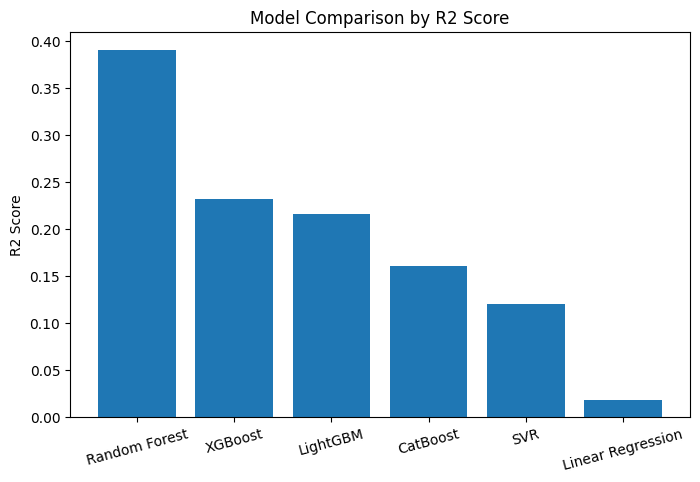

In [61]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['R2']
)

plt.ylabel("R2 Score")

plt.title("Model Comparison by R2 Score")

plt.xticks(rotation=15)

plt.show()

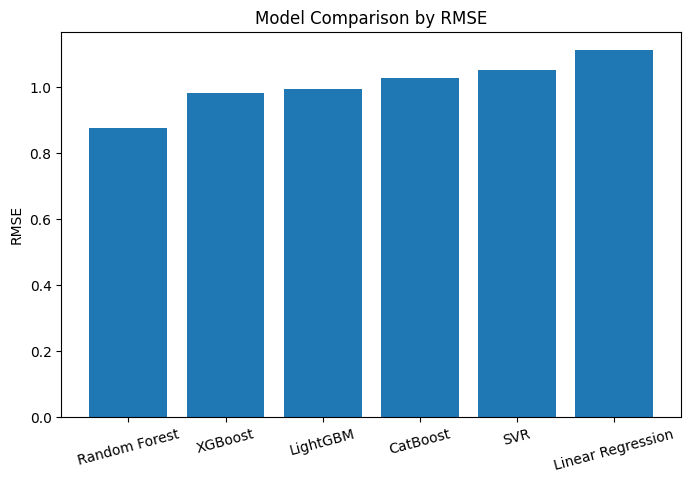

In [62]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.ylabel("RMSE")

plt.title("Model Comparison by RMSE")

plt.xticks(rotation=15)

plt.show()

Conclusion: The comparison of machine learning models demonstrated that nonlinear ensemble methods outperform linear approaches for anticancer activity prediction. Linear Regression showed almost no predictive capability (R² ≈ 0.02), indicating that the relationship between the selected molecular descriptors and pIC50 is highly nonlinear.
Among all tested models, Random Forest achieved the best performance (R² ≈ 0.39, RMSE ≈ 0.88), suggesting that tree-based ensemble methods are more suitable for modeling complex structure–activity relationships. XGBoost and LightGBM also demonstrated moderate predictive ability, although their performance was lower than that of Random Forest. CatBoost and SVR produced weaker results, while still outperforming Linear Regression.
Overall, the predictive performance of all models remained limited, which indicates that the six selected molecular descriptors (molecular weight, aLogP, HBA, HBD, PSA, and RTB) do not fully capture the structural complexity of anticancer compounds. The results suggest that more informative molecular representations are required for accurate QSAR modeling.
Therefore, the next step of the project should involve the use of cheminformatics tools such as RDKit to generate additional molecular descriptors and fingerprints (e.g., Morgan fingerprints, MACCS keys, and topological descriptors). This is expected to significantly improve model performance and provide a more realistic representation of molecular structure and anticancer activity relationships.